In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully')

All libraries imported successfully


In [3]:
df = pd.read_csv('../data/dataCleaned.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPrice stats:")
print(df['price'].describe())
df.head()

Shape: (96125, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize', 'brand']

Price stats:
count    96125.000000
mean     16567.395984
std       9472.798476
min       1000.000000
25%       9998.000000
50%      14200.000000
75%      20490.000000
max      99950.000000
Name: price, dtype: float64


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


In [5]:
print('=' * 60)
print('Dataset Overview')
print('=' * 60)

print(f'\n Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns \n')

print('Data Types:')
print(df.dtypes)

print('\n Missing Values by Column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No missing values found.')

print('\n Descriptive Statistics:')
df.describe()

Dataset Overview

 Dataset Dimensions: 96125 rows x 9 columns 

Data Types:
model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
mpg             float64
engineSize      float64
brand               str
dtype: object

 Missing Values by Column:
No missing values found.

 Descriptive Statistics:


,year,price,mileage,mpg,engineSize
count,96125.000000,96125.000000,96125.000000,96125.000000,96125.000000
mean,2017.035932,16567.395984,23618.443901,55.115521,1.665363
std,2.084389,9472.798476,20963.278605,13.434603,0.544939
min,1998.000000,1000.000000,100.000000,0.300000,1.000000
25%,2016.000000,9998.000000,8116.000000,47.100000,1.200000
50%,2017.000000,14200.000000,18066.000000,54.300000,1.600000
75%,2019.000000,20490.000000,32859.000000,62.800000,2.000000
max,2020.000000,99950.000000,241565.000000,470.800000,6.000000


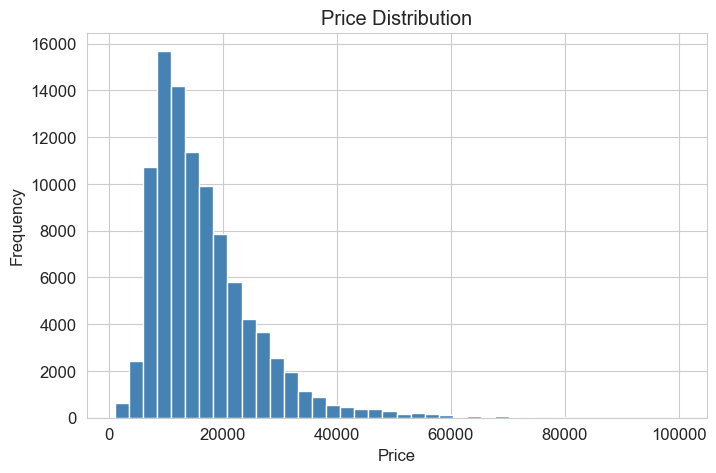

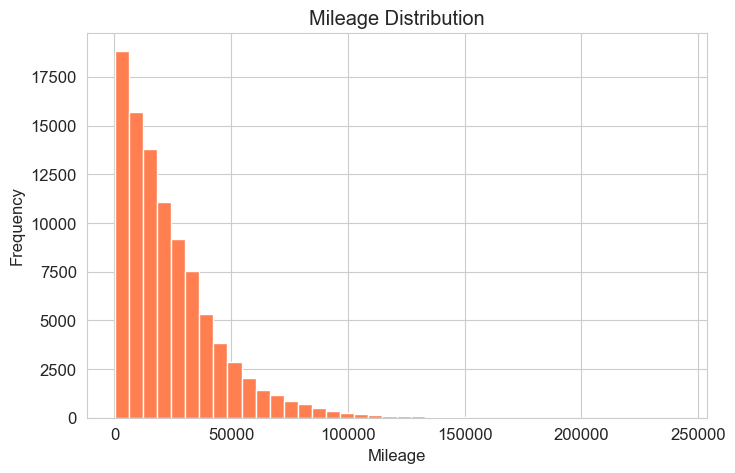

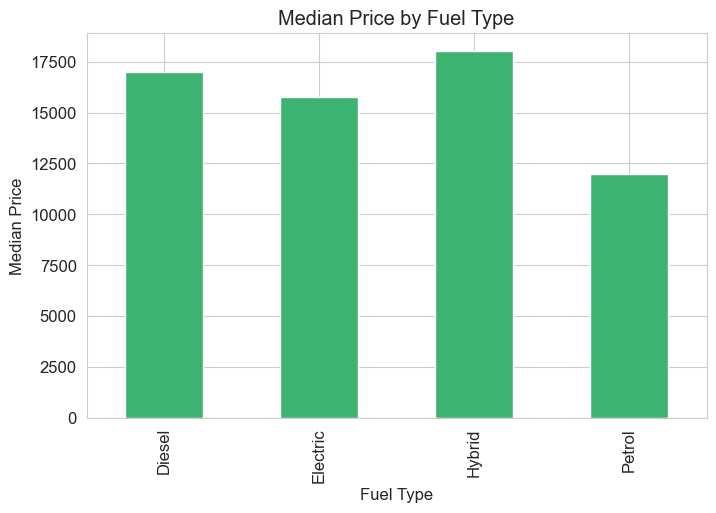

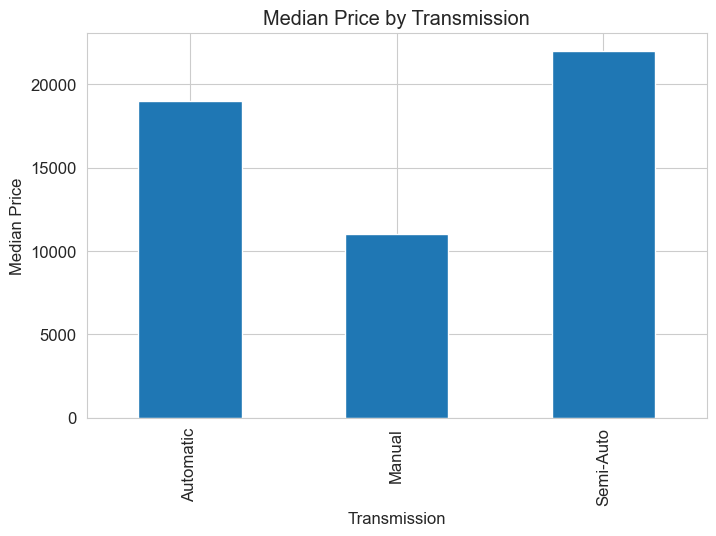

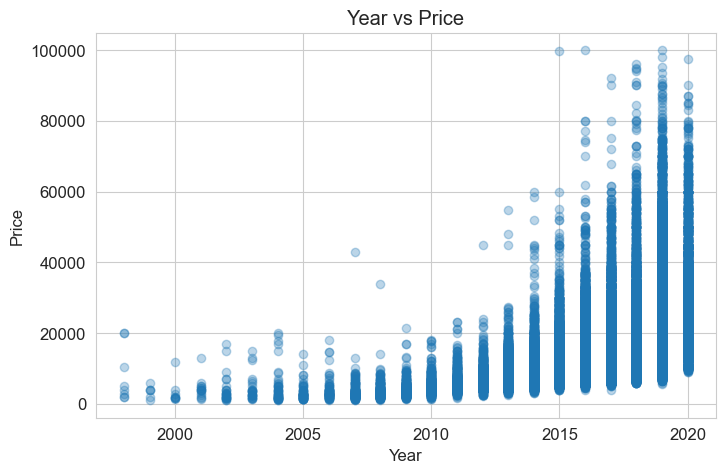

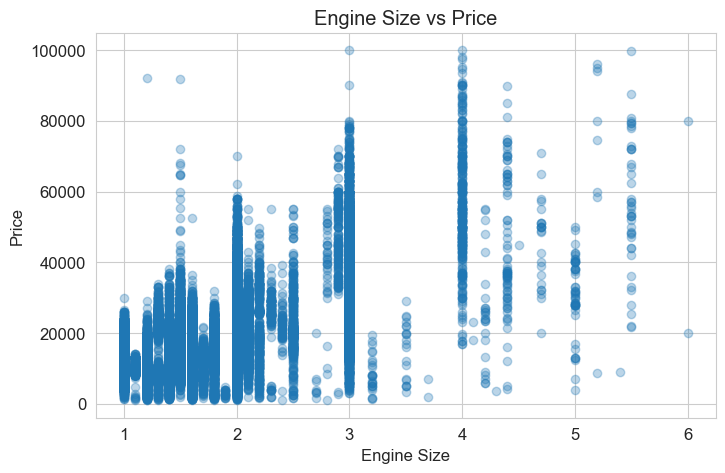

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['mileage'], bins=40, color='coral', edgecolor='white')
plt.title('Mileage Distribution')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))

df.groupby('fuelType')['price'].median().plot(
    kind='bar',
    color='mediumseagreen'
)

plt.title('Median Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Median Price')
plt.show()

plt.figure(figsize=(8,5))

df.groupby('transmission')['price'].median().plot(
    kind='bar'
)

plt.title('Median Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Median Price')
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['year'],
    df['price'],
    alpha=0.3
)

plt.title('Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['engineSize'],
    df['price'],
    alpha=0.3
)

plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()